# Foci counting
Detects peaks in a single timepoint scan and reports the number of detected foci and their fitting parameters

In [1]:
# Importing libraries
from kymotools.detect import Detector

import kymotools.io as kio
import numpy as np
import os

/Users/gfisher/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Documents/Papers/Fisher and Voulgaris et al 2025/Scripts used/.pixi/envs/default/lib/python3.12/site-packages/kymotools/io.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [ ]:
# Parameters
input_path = "./examples/input/" # Path to folder containing images to process
output_path = "./examples/output/" # Path to folder in which to save output
channel = 0 # Channel to process

In [3]:
# Defining process that will be applied to each scan
def process(input_path, output_path, name):
    # Loading image and rotating (kymotools detects along the y-axis)
    image = kio.read_image(input_path+name,channel,x_range=None)
    image = np.moveaxis(image,1,0)
    image = np.average(image,axis=1)
    image = image[...,np.newaxis]

    # Initialising Detector
    detector = Detector(half_t_w=0,peak_det_thresh = 2, n_max=40, a_lb = 0.5, c_lb=1, c_ub=6, c_def=4)

    # Detecting
    peaks = detector.fit_peaks(image[:,0])[0]

    # Saving peak data (position, sigma, etc.)
    rootname = os.path.splitext(name)[0]
    kio.write_peak_data(peaks, output_path+rootname+"_peaks.csv")

    # Saving peak fit image
    fig = kio.plot_gauss_for_frame(peaks,0,image,half_t_w=0)
    fig.savefig(output_path+rootname+"_peaks.png")


Processing:  20230324-145634 Scan 32_32_5 px crop


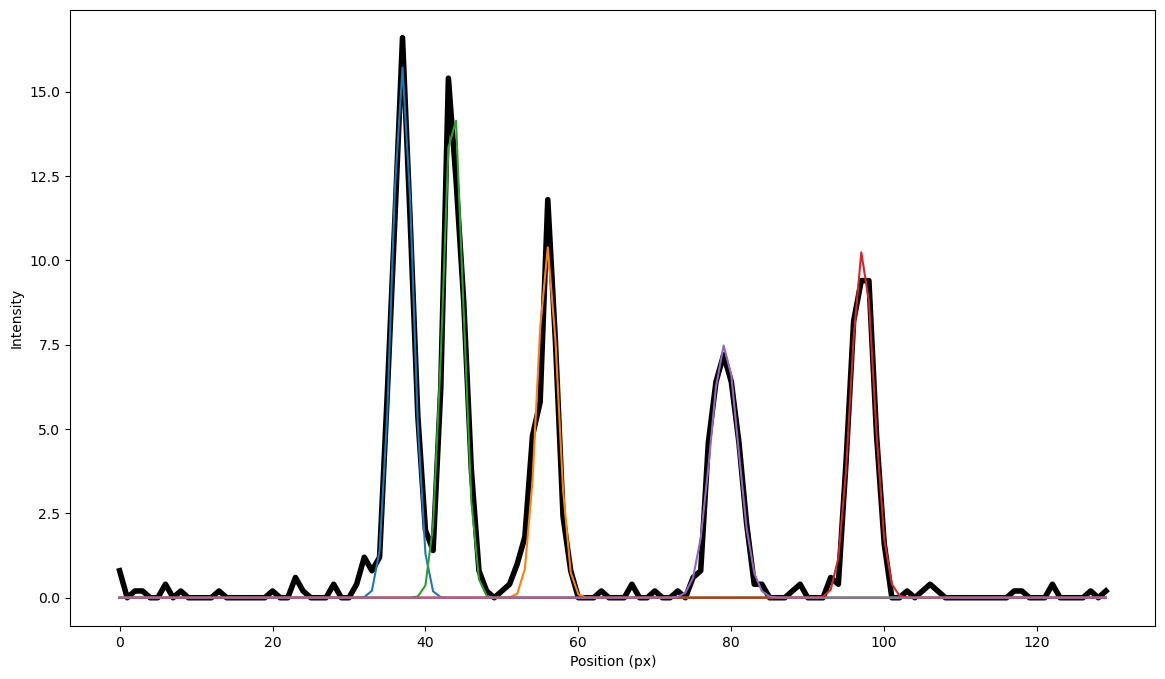

In [ ]:
# Batch processing all tif files in input folder
for name in os.listdir(input_path):
    if os.path.splitext(name)[1] == ".tif":
        print("Processing: ",name)
        process(input_path, output_path, name)